# E-Commerce Sales Analysis & BI Dashboard

Analysis of 100K+ Olist e-commerce orders using Python, MySQL, SQL, and Power BI.

## 1. Imports and Configuration

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import folium

In [3]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [4]:
pd.set_option("display.max_columns", None)
print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Database Connection

In [ ]:
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_USER = "root"
MYSQL_PASSWORD = "YOUR_PASSWORD"
MYSQL_DATABASE = "olist_ecommerce"

engine = create_engine(
    f"mysql+mysqlconnector://{MYSQL_USER}:{quote_plus(MYSQL_PASSWORD)}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

print("Database connected successfully")

Database connected successfully


## 3. Data Loading

In [6]:
orders = pd.read_sql("SELECT * FROM orders", engine)
order_items = pd.read_sql("SELECT * FROM order_items", engine)
payments = pd.read_sql("SELECT * FROM order_payments", engine)
reviews = pd.read_sql("SELECT * FROM order_reviews", engine)
customers = pd.read_sql("SELECT * FROM customers", engine)
products = pd.read_sql("SELECT * FROM products", engine)
geolocation = pd.read_sql("SELECT * FROM geolocation limit 50000", engine)

print("All tables loaded")

All tables loaded


## 4. Dataset Overview

In [7]:
tables = {
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "products": products,
    "geolocation": geolocation
}

for name, df in tables.items():
    print("=" * 50)
    print(name)
    print("Shape:", df.shape)
    print("Missing Values:", df.isnull().sum().sum())

orders
Shape: (99441, 8)
Missing Values: 4908
order_items
Shape: (112650, 7)
Missing Values: 0
payments
Shape: (103886, 5)
Missing Values: 0
reviews
Shape: (99224, 7)
Missing Values: 145903
customers
Shape: (99441, 5)
Missing Values: 0
products
Shape: (32951, 9)
Missing Values: 2448
geolocation
Shape: (50000, 5)
Missing Values: 0


## 5. Data Preprocessing

In [8]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)

orders["order_delivered_carrier_date"] = pd.to_datetime(
    orders["order_delivered_carrier_date"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

## 6. Monthly Revenue Analysis

In [ ]:
revenue_df = pd.read_sql("""
SELECT
    DATE_FORMAT(o.order_purchase_timestamp,'%Y-%m') AS month,
    ROUND(SUM(p.payment_value),2) AS revenue
FROM orders o
JOIN order_payments p
    ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month
""", engine)

revenue_df = revenue_df[
    revenue_df["month"] < "2018-09"
]

### Revenue Trend Visualization

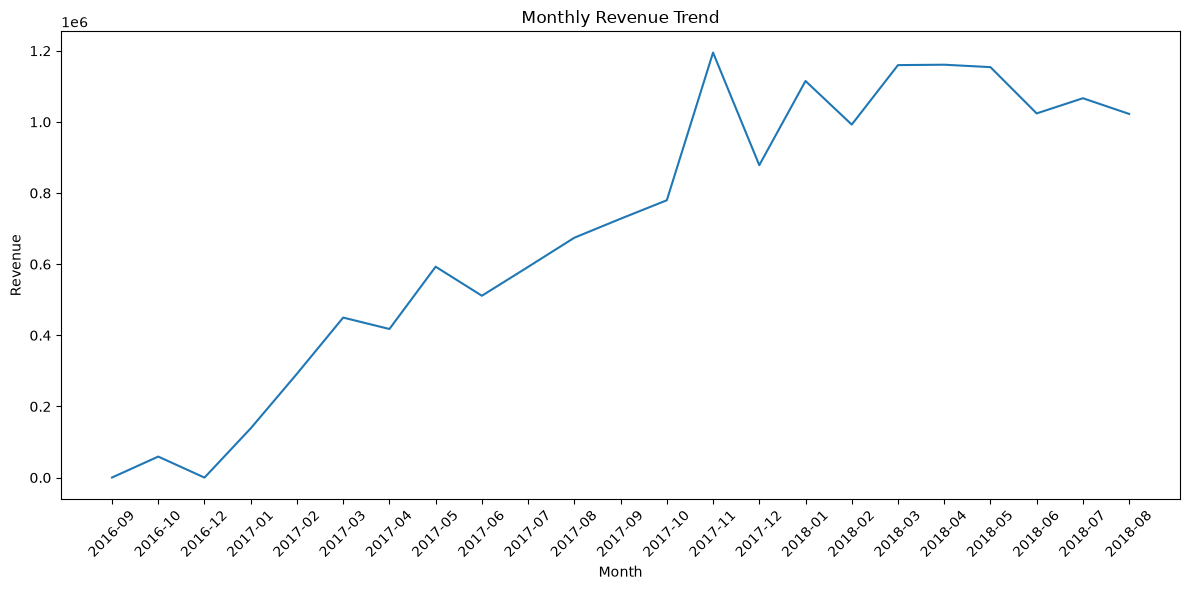

In [10]:
plt.figure(figsize=(12,6))

plt.plot(
    revenue_df["month"],
    revenue_df["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/figures/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Customer Segmentation (RFM Analysis)

RFM analysis evaluates customer value using:
- Recency
- Frequency
- Monetary Value

In [11]:
rfm = pd.read_sql("""
SELECT
    c.customer_unique_id,
    MAX(o.order_purchase_timestamp) AS last_purchase,
    COUNT(DISTINCT o.order_id) AS frequency,
    SUM(p.payment_value) AS monetary
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_payments p
    ON o.order_id = p.order_id
GROUP BY c.customer_unique_id
""", engine)

rfm.head()

,customer_unique_id,last_purchase,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


In [12]:
rfm["last_purchase"] = pd.to_datetime(
    rfm["last_purchase"]
)

snapshot_date = (
    rfm["last_purchase"].max()
    + pd.Timedelta(days=1)
)

rfm["recency"] = (
    snapshot_date - rfm["last_purchase"]
).dt.days

In [13]:
rfm = rfm[
    [
        "customer_unique_id",
        "recency",
        "frequency",
        "monetary"
    ]
]

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [14]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    4,
    labels=[4,3,2,1]
)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    4,
    labels=[1,2,3,4]
)

In [15]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

In [16]:
rfm["segment"] = np.where(
    rfm["RFM_Score"] == "444",
    "Champion",
    "Other"
)

rfm["segment"].value_counts()

segment
Other       94234
Champion     1861
Name: count, dtype: int64

In [17]:
rfm.to_csv(
    "../data/processed/rfm_segments.csv",
    index=False
)

print("RFM table saved")

RFM table saved


In [18]:
champions = rfm[rfm["segment"] == "Champion"]

print("Champion Customers:", len(champions))

print(
    "Champion Percentage:",
    round(len(champions) / len(rfm) * 100, 2),
    "%"
)

Champion Customers: 1861
Champion Percentage: 1.94 %


## 8. Geographic Analysis

In [19]:
state_counts = customers.groupby(
    "customer_state"
).size().reset_index(name="customers")

state_counts = state_counts.sort_values(
    "customers",
    ascending=False
)

state_counts.head(10)

,customer_state,customers
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [22]:
state_counts.head(10)

,customer_state,customers
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


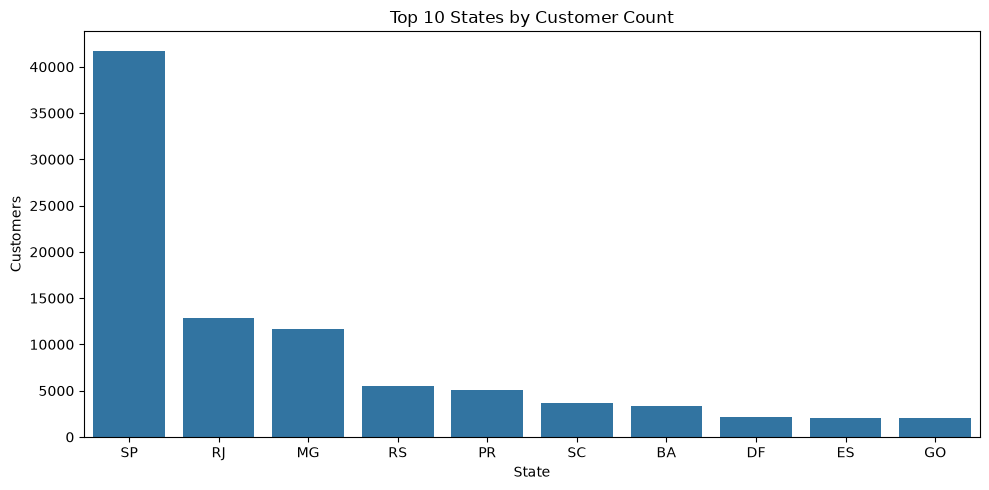

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=state_counts.head(10),
    x="customer_state",
    y="customers"
)

plt.title("Top 10 States by Customer Count")
plt.xlabel("State")
plt.ylabel("Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/top_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
brazil_map = folium.Map(
    location=[-14.2350, -51.9253],
    zoom_start=4
)

folium.Marker(
    location=[-23.5505, -46.6333],
    popup="São Paulo"
).add_to(brazil_map)

brazil_map

In [21]:
brazil_map.save(
    "../reports/figures/brazil_map.html"
)

print("Brazil map saved")

Brazil map saved


## 9. Key Findings

1. Monthly revenue exceeded 1M BRL during multiple months in 2018.
2. Health & Beauty was the highest revenue-generating category.
3. Credit cards accounted for the majority of transactions and revenue.
4. Approximately 8.11% of deliveries were late.
5. São Paulo showed the fastest average delivery performance.
6. Only 2,997 customers placed more than one order.
7. RFM segmentation identified 1,861 Champion customers (~1.94% of customers).

## Conclusion

This analysis explored customer behavior, revenue trends,
payment preferences, delivery performance, and customer
segmentation using the Olist E-Commerce dataset.

The results provide actionable insights for customer
retention, logistics optimization, and revenue growth.